# Notebook 1 - Disorder linewidth tutorial

This notebook is the first of the series that introduces the concept of disorder linewidth in disordered systems and obtains it from the difference between VDOS of a disordered glass and a reference crystal. We will first obtain the band structure of graphite and compare available vibrational information between crystals and glasses.

## Boltzmann transport equation (BTE) within relaxation time approximation for crystals

Here we will show the phonon band structure in crystal graphite and see how band structure picture breaks down in disordered solids

### BTE for crystals

Crystal is a periodic arrangement of atoms. As a consequence, lattice vibrations — **phonons** — are characterised by a wavevector $\mathbf{q}$ in the first Brillouin zone (BZ) and a branch index $s$. The phonon **band structure** $\omega_{\mathbf{q},s}$ is obtained by diagonalising the dynamical matrix

$$ \sum_{b' \alpha' } D(\mathbf{q})_{b \alpha, b' \alpha'} \mathcal{E}(\mathbf{q})_{s, b' \alpha'} = \omega^2_{\mathbf{q},s} \mathcal{E}(\mathbf{q})_{s, b \alpha},$$

The **group velocity** of each mode,

$$\mathbf{v}_{\mathbf{q},s} = \frac{\partial \omega_{\mathbf{q},s}}{\partial \mathbf{q}},$$

quantifies how fast that phonon mode travels through the crystal.

**Thermal conductivity within the BTE in the Relaxation Time Approximation (RTA):**

$$\kappa = \sum_{\mathbf{q},s} C_{\mathbf{q},s}\, D_{\mathbf{q},s}, \qquad D_{\mathbf{q},s} = \frac{v_{\mathbf{q},s}^2/3}{\Gamma_{\mathbf{q},s}(T)},$$

where $C_{\mathbf{q},s}$ is the quantum (Bose-Einstein) heat capacity per mode and $D_{\mathbf{q},s}$ is the **mode diffusivity**. The **linewidth** $\Gamma_{\mathbf{q},s}(T)$ is the total phonon scattering rate; it can have two physically distinct origins:

- **Anharmonic scattering** (3-, 4-phonon processes): temperature-dependent, dominant at high $T$.
- **Perturbative disorder scattering** (point defects, grain boundaries, vacancies): largely temperature-independent.

In this notebook you will explore crystal graphite — examining its band structure and group velocities — and then contrast it with irradiated (disordered) graphite.

## Crystal graphite

We begin by importing the necessary libraries and loading the pre-computed force constants for crystal graphite.

In [1]:
import os
import sys

import h5py
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import ase
from ase.io import read

from tqdm import tqdm

from smooth_disorder.structural import obtain_density, THzToCm, THz, Angstrom
from smooth_disorder.vis.interactive import *

from smooth_disorder.disorder_linewidth import run_band_structure_manual
from smooth_disorder.disorder_linewidth import run_phonon_mesh, save_mesh_data_to_files

from phonopy import Phonopy
from phonopy import file_IO as phonopy_file_IO

from phonopy.interface.calculator import read_crystal_structure
from phonopy.phonon.band_structure import get_band_qpoints_and_path_connections

Set the file paths to the crystal POSCAR and FC2 file, define the supercell matrix and BZ mesh size, and prepare the output directory where results will be saved for use in later notebooks.

In [2]:
CRYSTAL_POSCAR   = "./1_graphite/POSCAR"
CRYSTAL_FC2      = "./1_graphite/fc2.hdf5"
SUPERCELL_MATRIX = np.diag([8, 8, 2])
MESH             = [128, 128, 32]
GAMMA_CENTER     = True

WORK_DIR = "./dl_tutorial"
os.makedirs(WORK_DIR, exist_ok=True)

MESH_SAVE        = f"{WORK_DIR}/mesh_data"

In [3]:
# Special BZ points for hexagonal graphite — fractional reciprocal-lattice coordinates
atoms_ase = ase.io.read(CRYSTAL_POSCAR)
ase.dft.kpoints.get_special_points(atoms_ase.cell)

{'G': array([0., 0., 0.]),
 'A': array([0. , 0. , 0.5]),
 'H': array([0.33333333, 0.33333333, 0.5       ]),
 'K': array([0.33333333, 0.33333333, 0.        ]),
 'L': array([0.5, 0. , 0.5]),
 'M': array([0.5, 0. , 0. ])}

In [4]:
# Preferred path Γ→A→L→M→Γ→K→H
# Segment 1 (Γ→A): [0,0,0]→[0,0,0.5] — purely out-of-plane (z direction)
# Segments 4+5 (M→Γ and Γ→K): kz=0 throughout — purely in-plane (xy plane)
# Other segments (A→L, L→M, K→H): mixed in-plane and out-of-plane character
path = [[[0, 0, 0], [0. , 0. , 0.5], [0.5, 0. , 0.5], [0.5, 0. , 0. ],
         [0., 0., 0.], [0.33333333, 0.33333333, 0.], [0.33333333, 0.33333333, 0.5]]]
labels = ["$\\Gamma$", "A", "L", "M", "$\\Gamma$", "K", "H"]

We use `run_band_structure_manual` to compute the phonon frequencies along the chosen high-symmetry path and plot the resulting band structure. Each line is one phonon branch $\omega_{\mathbf{q},s}$ as a function of $\mathbf{q}$.

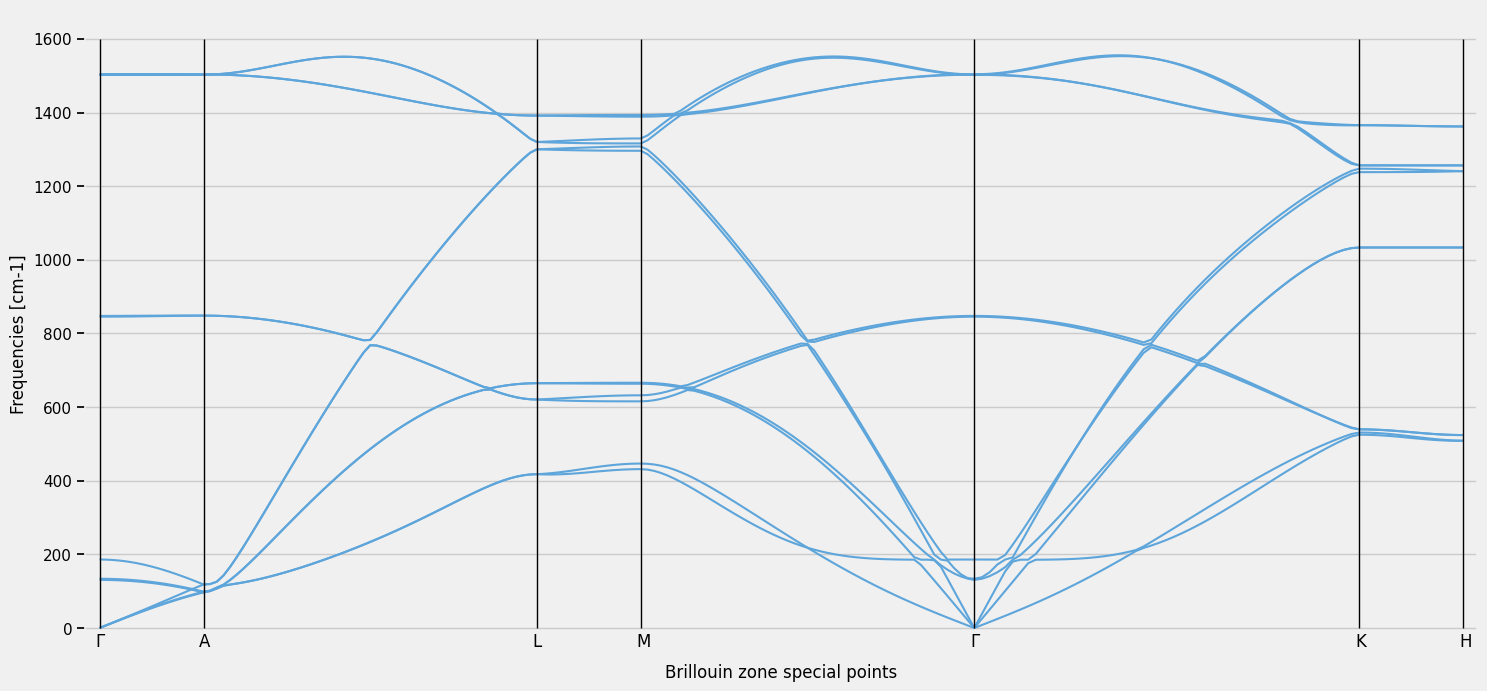

In [5]:
frequencies, distances, qpoints = run_band_structure_manual(CRYSTAL_POSCAR, CRYSTAL_FC2, SUPERCELL_MATRIX, path, labels)

num_paths = len(distances)
num_modes = frequencies[0].shape[1]

plt.figure(figsize=(16, 8))

for path in range(num_paths):
    for mode in range(num_modes):
        plt.plot(distances[path], frequencies[path][:, mode]*THzToCm, color=Colors[3])

y_min, y_max = 0, 1600
plt.vlines(0.0, y_min, y_max, color="black", lw=1)
plt.text(0.0-0.003, -50, labels[0])

for path in range(num_paths):
    plt.vlines(distances[path][-1], y_min, y_max, color="black", lw=1)
    plt.text(distances[path][-1]-0.003, -50, labels[path+1])

plt.ylabel("Frequencies [cm-1]")
plt.xlabel("Brillouin zone special points")

plt.xlim([-0.01, np.max(distances)+0.01])
plt.xticks([])
plt.show()

The next cell computes phonon frequencies and group velocities on a dense $128 \times 128 \times 32$ BZ mesh using `run_phonon_mesh`. **Warning: this calculation can take couple of minutes.** The result is saved to an HDF5 file and reused in all subsequent notebooks — you only need to run it once.

In [6]:
%%time
mesh_dict = run_phonon_mesh(CRYSTAL_POSCAR, CRYSTAL_FC2, SUPERCELL_MATRIX, MESH, GAMMA_CENTER)

save_mesh_data_to_files(MESH_SAVE,
                        mesh_dict['frequencies_cm'],
                        mesh_dict['weights'],
                        mesh_dict['qpoints'],
                        mesh_dict['group_velocities_ms'])

CPU times: user 1min 1s, sys: 258 ms, total: 1min 1s
Wall time: 1min 1s


Load the phonon mesh data saved in the previous step: frequencies (in cm$^{-1}$), BZ weights, $\mathbf{q}$-points, and group velocities (in m/s).

In [7]:
with h5py.File(f"{MESH_SAVE}.hdf5", "r") as f:
    frequencies_cm      = np.asarray(f["frequencies_cm"])       # (N_qpts, N_bands) [cm⁻¹]
    weights             = np.asarray(f["weights"])              # (N_qpts,)
    qpoints             = np.asarray(f["qpoints"])              # (N_qpts, 3) fractional
    group_velocities_ms = np.asarray(f["group_velocities_ms"])  # (N_qpts, N_bands, 3) [m/s]

For each mode $(\mathbf{q}, s)$, compute the scalar group speed as the RMS over Cartesian components,

$$|\mathbf{v}_{\mathbf{q},s}| = \sqrt{\frac{v_x^2 + v_y^2 + v_z^2}{3}},$$

and plot it as a scatter point against frequency. Each dot represents one phonon mode on the BZ mesh.

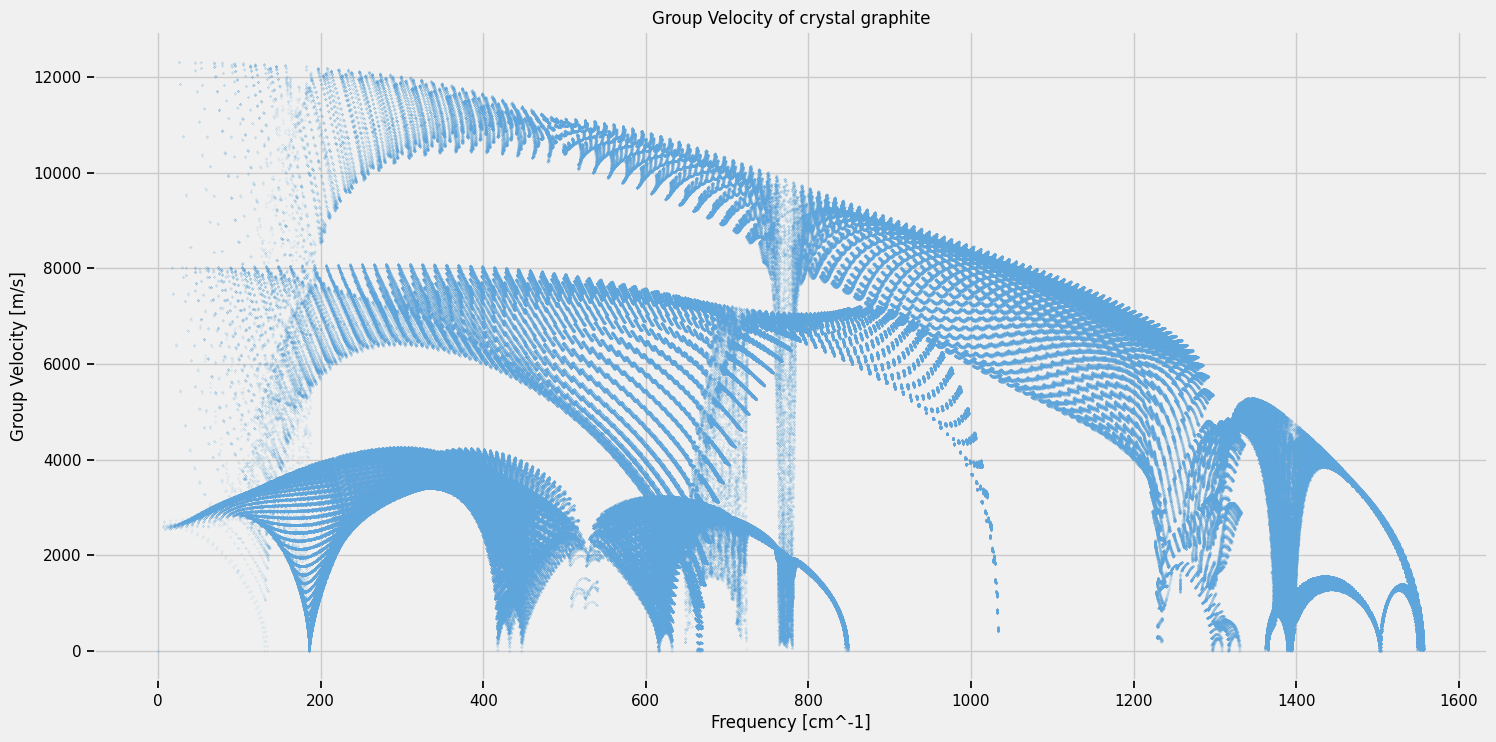

In [8]:
plt.figure(figsize=(16, 8))

speed_2d = np.sqrt(
    np.square(group_velocities_ms).sum(axis=2) / 3
)

plt.scatter(frequencies_cm, speed_2d, color=Colors[3], s=0.01)


plt.xlabel("Frequency [cm^-1]")
plt.ylabel("Group Velocity [m/s]")

plt.title("Group Velocity of crystal graphite")

plt.show()

**Summary — BTE in crystals:**

We see that in the crystal, modes have both well-defined harmonic frequencies and nonzero group velocities, both can be calculated from the band structure. We find this picture breaks down in disordered solids.

## Disordered Irradiated Graphite

Ion irradiation introduces point defects (vacancies, interstitials) and disrupts the long-range crystalline order. As a consequence, there is no longer a well-defined band structure, and therefore no per-mode group velocity. 

We find in disordered systems, heat travels via tunnelling mechanism between two modes and because of frequency repulsion, modes can be distinguished by their frequency. We can write the formula for thermal conductivity as:

$$\kappa = \int d\omega\, g(\omega)\, C(\omega, T)\, D(\omega, T),$$

where $g(\omega)$ is the **Vibrational Density of States** (VDOS), $C(\omega, T)$ is the heat capacity per mode, and $D(\omega, T)$ is the frequency-resolved **diffusivity**. Unlike in BTE model for simple crystals, $D(\omega)$ is calculated within Wigner formulation of thermal transport from couplings between pairs of vibrational modes (off-diagonal elements of the velocity operator) rather than from group velocities — see PRX 15, 041041 (2025), https://doi.org/10.1103/w4p6-b9mp for details.

Below we plot $g(\omega)$ and $D(\omega)$ for irradiated graphite (IRG T2).

Import the functions needed to compute the VDOS from a set of pre-computed disordered-system frequencies.

In [9]:
from smooth_disorder.disorder_linewidth import lorentzian_numpy, flatten_arrays_freq_only
from smooth_disorder.disorder_linewidth import calculate_vdos_with_frequency
from smooth_disorder.disorder_linewidth import save_vdos_data_to_files

Set the paths to the disordered structure (POSCAR), its pre-computed vibrational frequencies, and the pre-computed diffusivity. Also set the Lorentzian broadening parameter $\eta = 0.6$ cm$^{-1}$, which controls the spectral resolution of the VDOS.

In [10]:
DISORDERED_POSCAR      = "./2_irg_t2/irg_t2_14009.vasp"
DISORDERED_FREQUENCIES = "./2_irg_t2/irg_t2_frequencies.hdf5"
DISORDERED_DIFFUSIVITY = "./2_irg_t2/diffusivity.hdf5"

DISORDERED_VDOS_SAVE  = f"{WORK_DIR}/disordered_vdos"

# Lorentzian half-width η for VDOS broadening [cm⁻¹].
# Controls spectral resolution — typical value for graphite: 0.6 cm⁻¹.
GAMMA_BROADENING = 0.6

Load the pre-computed disordered frequencies, flatten them to a 1D array, and compute the VDOS by summing Lorentzian peaks of half-width $\eta$ centred on each frequency (all handled by the prepared code).

In [11]:
with h5py.File(DISORDERED_FREQUENCIES, "r") as f:
    print(f.keys())
    frequencies = np.asarray(f['frequencies'])  # these are already saved in cm^-1
    weights = np.asarray(f['weights'])


frequencies_flat, weights_flat, weights_sum = flatten_arrays_freq_only(frequencies, weights)

vdos_disordered, freq_disordered = calculate_vdos_with_frequency(
    frequencies_flat,
    weights_flat,
    GAMMA_BROADENING,
    DISORDERED_POSCAR,
    weights_sum
)

<KeysViewHDF5 ['frequencies', 'weights']>


VDOS & v(w): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 17104/17104 [00:00<00:00, 17532.29it/s]


Plot the VDOS $g(\omega)$ of IRG T2.

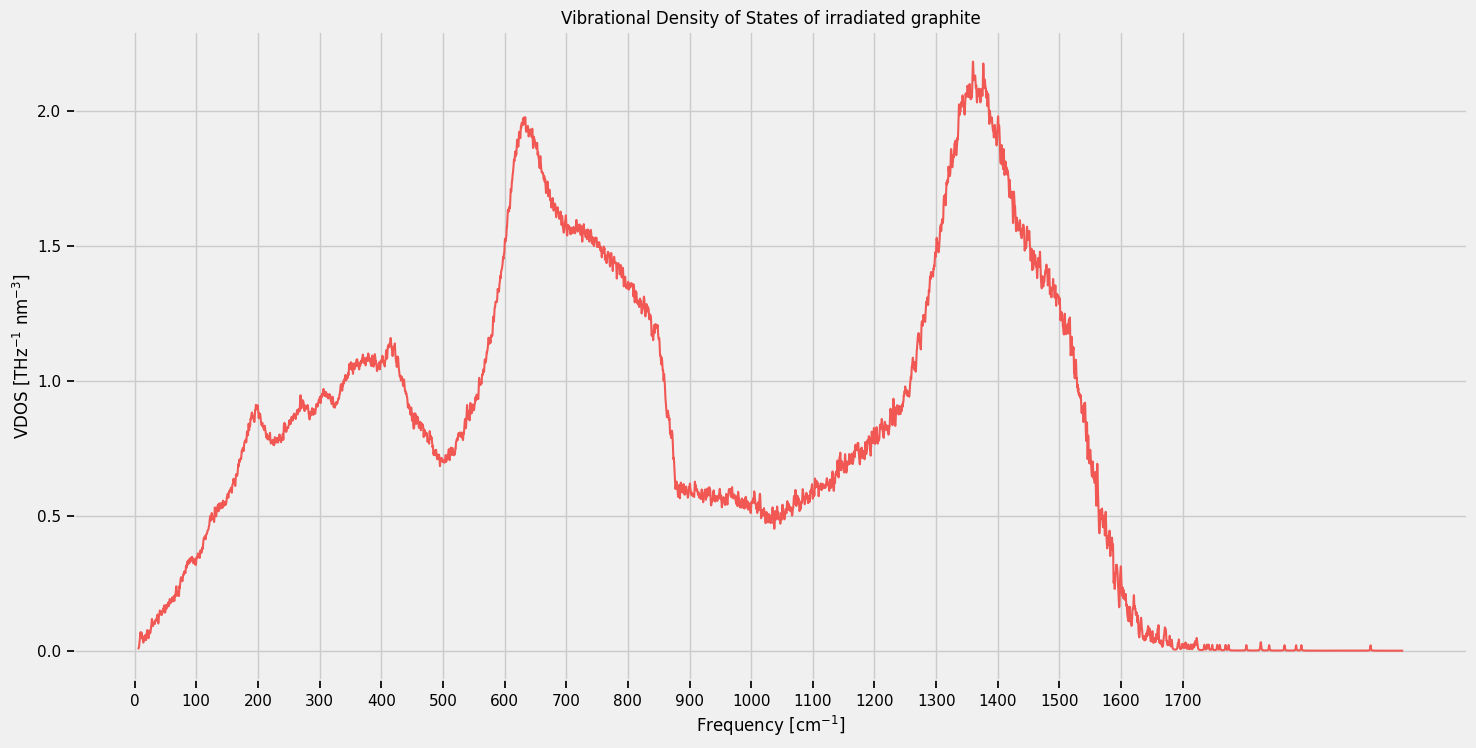

In [12]:
plt.figure(figsize=(16, 8))

plt.plot(freq_disordered, vdos_disordered, color=Colors[0])

plt.xlabel("Frequency [cm$^{-1}$]")
plt.ylabel("VDOS [THz$^{-1}$ nm$^{-3}$]")

plt.title("Vibrational Density of States of irradiated graphite")

plt.xticks(np.arange(0, 1800, 100))

plt.show()

Save the VDOS to HDF5 for use in later notebooks.

In [13]:
save_vdos_data_to_files(DISORDERED_VDOS_SAVE, freq_disordered, vdos_disordered)

Load the pre-computed diffusivity $D(\omega)$ of IRG T2.

In [14]:
# read in the diffusivity
with h5py.File(DISORDERED_DIFFUSIVITY, "r") as f:
    print(f.keys())
    diffusivity_plot = np.asarray(f["diffusivity"])  # in m^2/s
    frequencies_plot_diff = np.asarray(f["frequencies_plot"])  # in cm^-1

<KeysViewHDF5 ['diffusivity', 'frequencies_plot']>


Plot the diffusivity $D(\omega)$ of IRG T2.

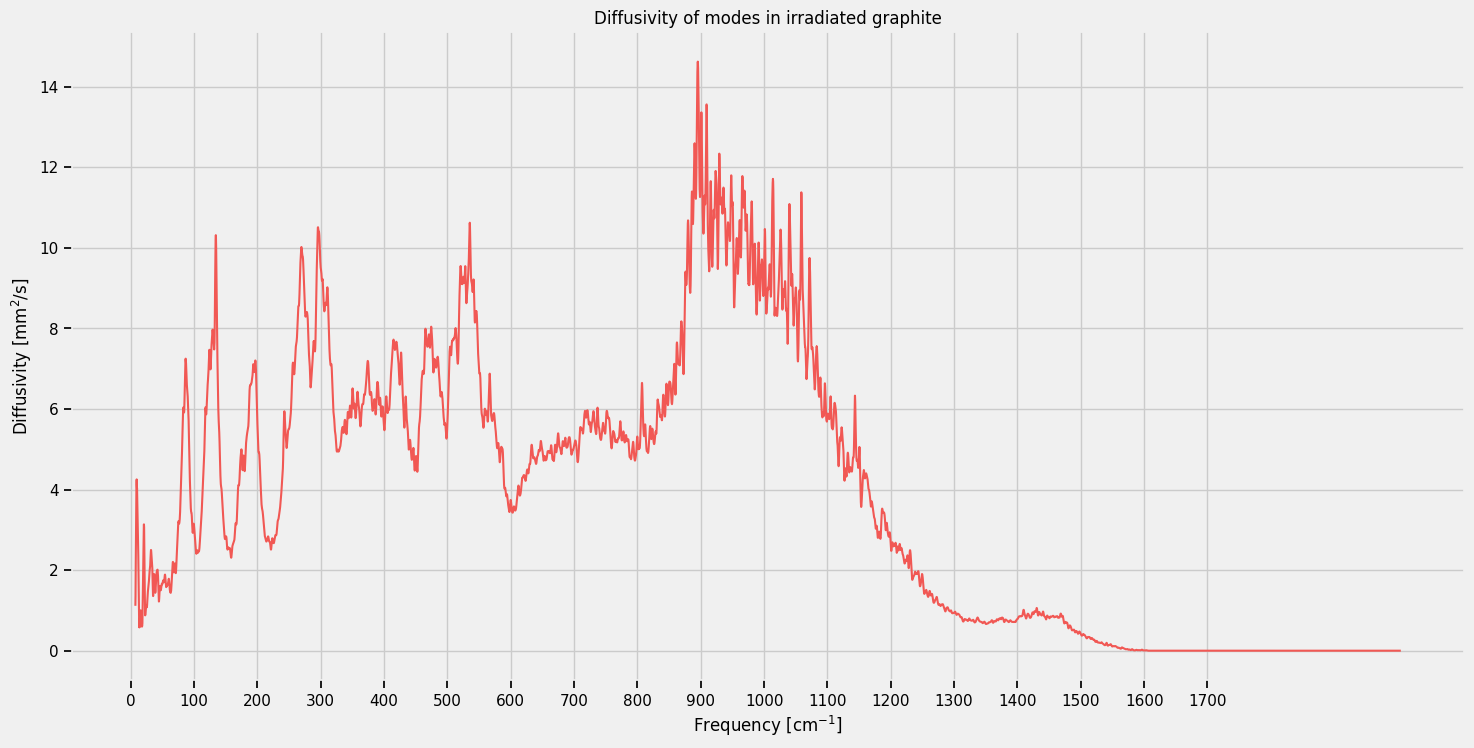

In [15]:
plt.figure(figsize=(16, 8))

plt.plot(frequencies_plot_diff, diffusivity_plot*1e6, color=Colors[0])

plt.xlabel("Frequency [cm$^{-1}$]")
plt.ylabel("Diffusivity [mm$^2$/s]")

plt.title("Diffusivity of modes in irradiated graphite")

plt.xticks(np.arange(0, 1800, 100))

plt.show()

In this notebook we have seen that **crystal graphite** possesses a well-defined phonon band structure, enabling a per-mode calculation of both group velocity (shown above) and relaxation time $\Gamma_{\mathbf{q},s}$. In **irradiated graphite**, long-range periodicity is broken, and only the frequency-resolved VDOS $g(\omega)$ and diffusivity $D(\omega)$ are accessible.

The goal of the subsequent notebooks is to build intuition about thermal transport in disordered systems — in particular, how to decompose $D(\omega)$ into a propagation velocity and a mean free path, and understand their dependence on structural disorder.